<a href="https://colab.research.google.com/github/helsach/2025_pengolahan_citra_ti2b/blob/main/Jobsheet_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Helsa Christabel Harsono (4.33.23.1.10)

## Jobsheet 4: Segmentasi Gambar

### Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

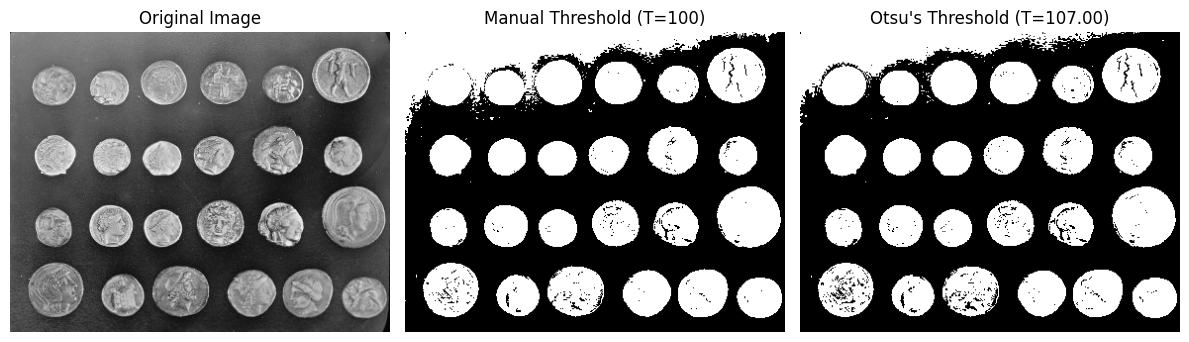

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# Memuat citra (contoh: coins)
image_coins = data.coins()

# Thresholding Global  (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

### Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

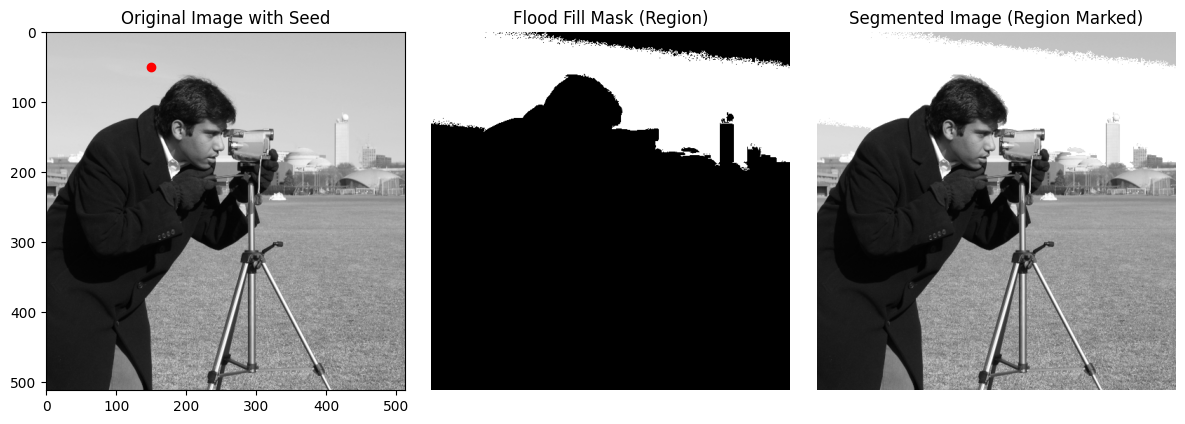

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# Memuat citra (contoh: camera)
image_camera = data.camera()

# Tentukan titik seed (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

# Terapkan algoritma flood fill (mirip reion growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[1].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

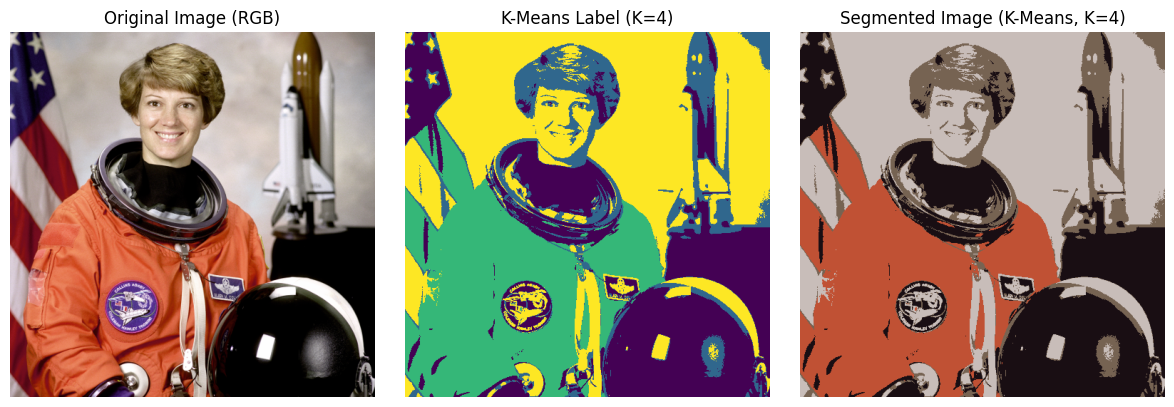

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# Memuat citra berwarna (contoh:astronaut)
image_astro = data.astronaut()
# konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# Reshape citra menjadi array piksel [jumlah_piksel, jumlah fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk resepsi warna
# konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)


# Terapkan K-Means Clustering
# tentukan jumlah klaster(segmen) yang diinginkan, misal K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
# Hiding FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# Buat citra segmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Label (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


### Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

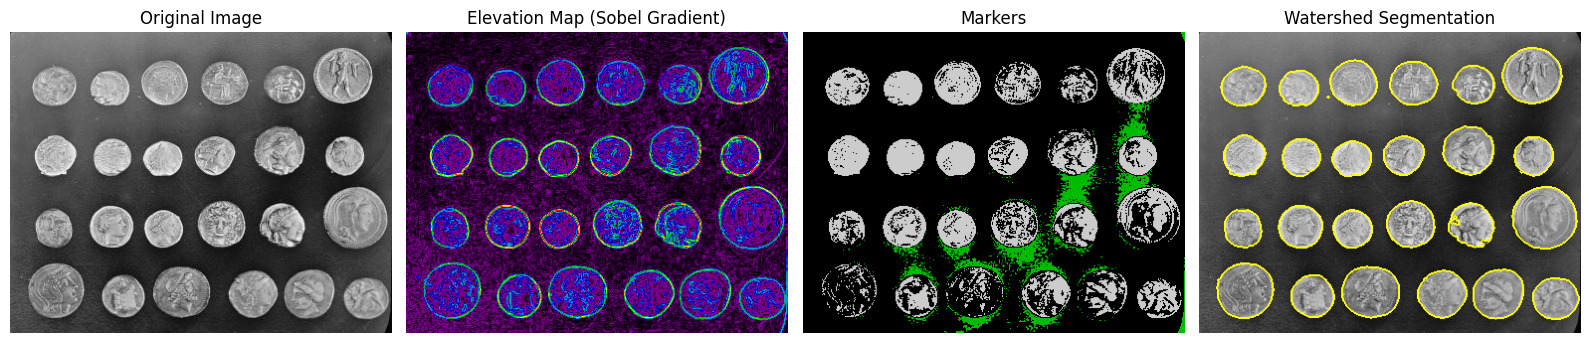

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, morphology, segmentation, measure
from scipy import ndimage as ndi

# Memuat citra (contoh: coins)
image_coins = data.coins()

# Hitung gradien citra (sebagai 'topografi)
elevation_map = filters.sobel(image_coins)

# Tentukan marker (penanda awal untuk setiap cekungan/objek)
# kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

# Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmentation_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# Visualisasi hasilac
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmentation_colored, cmap=plt.cm.gray)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### Praktikum 5. Perbandingan Visual Hasil Segmentasi

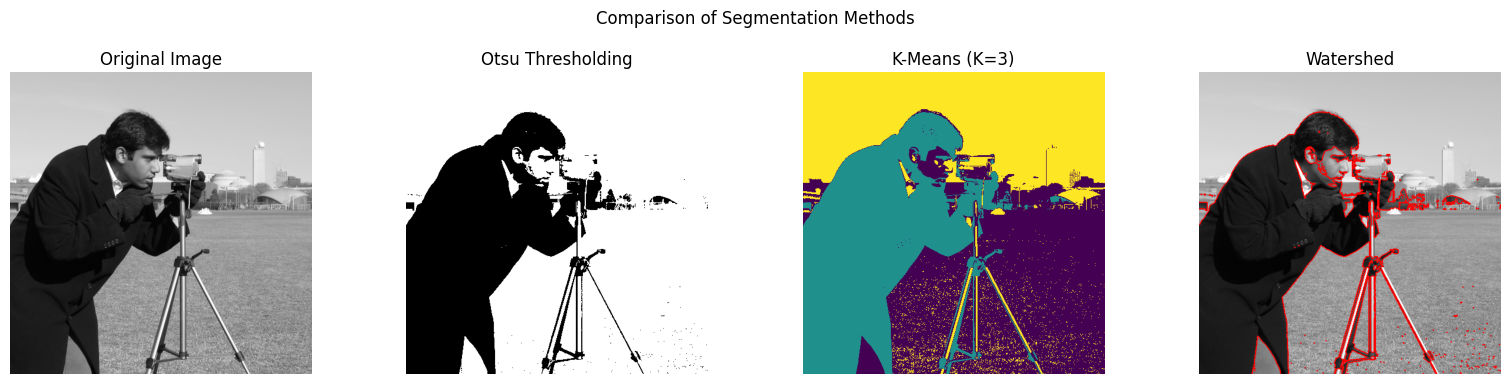

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis') # Gunakan cmap berbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1,0,0)) # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()


### Tugas (Eksperimen Tresholding)

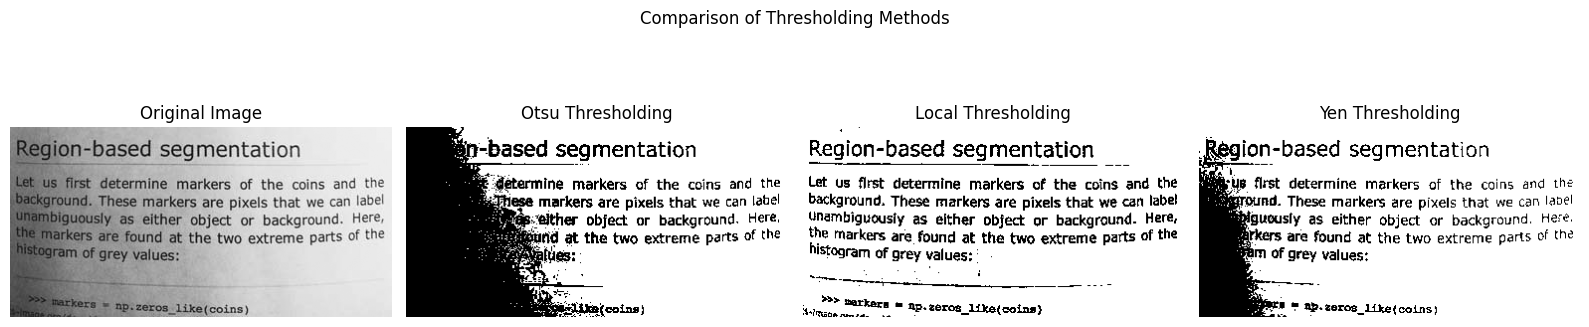

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage import img_as_float

# Memuat citra
image = data.page()

# Konversi citra ke format float untuk perhitungan
image_float = img_as_float(image)

# Terapkan Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# Terapkan Thresholding Local
thresh_local = filters.threshold_local(image, block_size=35, offset=10)
binary_local = image > thresh_local

# Terapkan Thresholding Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# Visualisasi Hasil
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap=plt.cm.gray)
ax[2].set_title('Local Thresholding')
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title('Yen Thresholding')
ax[3].axis('off')

plt.suptitle('Comparison of Thresholding Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()


### Tugas 2

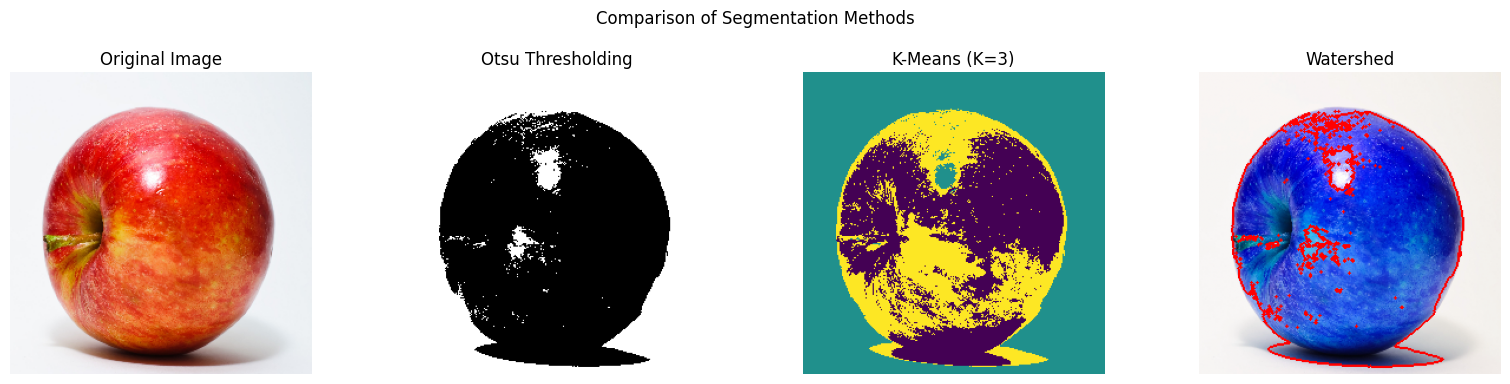

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import urllib.request
import warnings

# Unduh gambar apel dari Wikimedia
url = "https://upload.wikimedia.org/wikipedia/commons/1/15/Red_Apple.jpg"
urllib.request.urlretrieve(url, "apple.jpg")

# Baca gambar
image = cv2.imread("apple.jpg")
image = cv2.resize(image, (256, 256))  # Ukuran lebih kecil untuk efisiensi

# Konversi citra ke grayscale untuk Otsu Thresholding
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_float = img_as_float(image)

# Otsu Thresholding
thresh_otsu = filters.threshold_otsu(gray)  # Terapkan Otsu pada citra grayscale
binary_otsu = gray > thresh_otsu

# K-Means Clustering
rows, cols = image.shape[:2]
pixel_features = image_float.reshape(rows * cols, 3)  # Menggunakan 3 fitur (RGB)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Melakukan klasterisasi
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# Watershed Segmentation
elevation_map = filters.sobel(gray)  # Gunakan grayscale untuk peta elevasi
markers = np.zeros_like(gray)
markers[gray < thresh_otsu] = 1
markers[gray > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

# Gambar asli
ax[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

# Hasil Otsu Thresholding
ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

# Hasil K-Means
ax[2].imshow(segmented_kmeans_labels, cmap='viridis')  # Gunakan cmap berbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Hasil Watershed
segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))  # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

# Set judul umum
plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for suptitle
plt.show()